In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

In [3]:
url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
df = pd.read_csv(url, compression='zip')

print(df.head())

             Date Time  p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
0  01.01.2009 00:10:00    996.52     -8.02    265.40        -8.90    93.3   
1  01.01.2009 00:20:00    996.57     -8.41    265.01        -9.28    93.4   
2  01.01.2009 00:30:00    996.53     -8.51    264.91        -9.31    93.9   
3  01.01.2009 00:40:00    996.51     -8.31    265.12        -9.07    94.2   
4  01.01.2009 00:50:00    996.51     -8.27    265.15        -9.04    94.1   

   VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  H2OC (mmol/mol)  \
0          3.33          3.11          0.22       1.94             3.12   
1          3.23          3.02          0.21       1.89             3.03   
2          3.21          3.01          0.20       1.88             3.02   
3          3.26          3.07          0.19       1.92             3.08   
4          3.27          3.08          0.19       1.92             3.09   

   rho (g/m**3)  wv (m/s)  max. wv (m/s)  wd (deg)  
0       1307.75      1.03        

In [4]:
data = df[['T (degC)']].values   # Temperature column

In [5]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [6]:
def create_sequences(data, time_steps=24):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps])
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled)

In [7]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

model = Sequential([
    SimpleRNN(50, return_sequences=True, input_shape=(24, 1)),
    Dropout(0.2),
    SimpleRNN(50),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 24, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history_20 = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 65s 6ms/step - loss: 0.0018 - val_loss: 3.7306e-05
Epoch 2/20
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 75s 5ms/step - loss: 1.8823e-04 - val_loss: 1.5165e-05
Epoch 3/20
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 57s 5ms/step - loss: 1.8004e-04 - val_loss: 7.6089e-05
Epoch 4/20
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 57s 5ms/step - loss: 1.7459e-04 - val_loss: 6.2534e-05
Epoch 5/20
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 56s 5ms/step - loss: 1.7355e-04 - val_loss: 4.4811e-05
Epoch 6/20
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 58s 5ms/step - loss: 1.7102e-04 - val_loss: 3.9719e-05
Epoch 7/20
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 57s 5ms/step - loss: 1.7173e-04 - val_loss: 4.6711e-05
Epoch 8/20
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 57s 5ms/step - loss: 1.6846e-04 - val_loss: 2.6672e-05
Epoch 9/20
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 57s 5ms/step - loss: 1.6513e-04 - val_loss: 1.4662e-05
Epoch 10/20
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 56s 5ms/step - loss: 1.6307e-04 - val_loss: 5.7395e-05
Epoch 11/20
1

In [10]:
history_50 = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/50
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 58s 6ms/step - loss: 1.4930e-04 - val_loss: 3.0892e-05
Epoch 2/50
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 80s 5ms/step - loss: 1.4918e-04 - val_loss: 4.1765e-05
Epoch 3/50
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 57s 5ms/step - loss: 1.4991e-04 - val_loss: 3.5206e-05
Epoch 4/50
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 61s 6ms/step - loss: 1.4909e-04 - val_loss: 3.3009e-05
Epoch 5/50
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 77s 5ms/step - loss: 1.4965e-04 - val_loss: 3.6339e-05
Epoch 6/50
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 57s 5ms/step - loss: 1.4748e-04 - val_loss: 1.7900e-05
Epoch 7/50
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 57s 5ms/step - loss: 1.4845e-04 - val_loss: 3.3478e-05
Epoch 8/50
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 56s 5ms/step - loss: 1.4721e-04 - val_loss: 3.3251e-05
Epoch 9/50
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 57s 5ms/step - loss: 1.4938e-04 - val_loss: 1.9490e-05
Epoch 10/50
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 82s 5ms/step - loss: 1.4852e-04 - val_loss: 3.3953e-05
Epoch 11/

In [11]:
y_pred = model.predict(X_test)

# Inverse scaling
y_test_actual = scaler.inverse_transform(y_test)
y_pred_actual = scaler.inverse_transform(y_pred)

2629/2629 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step


In [12]:
mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.19353277272545089
RMSE: 0.27563290464978296


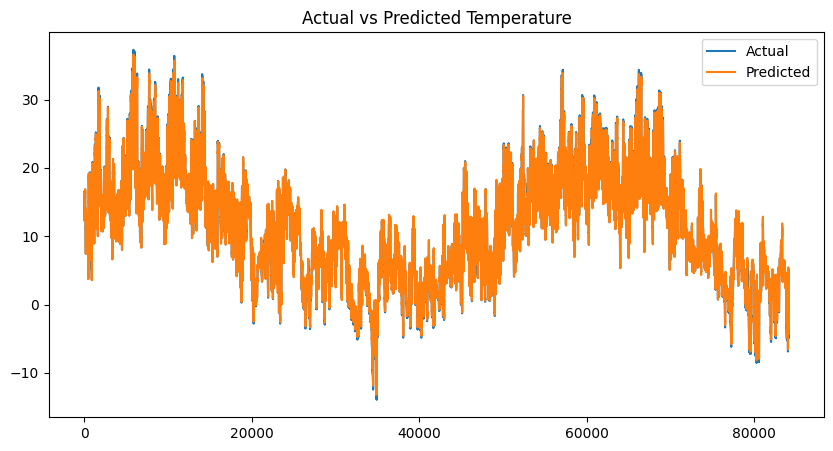

In [13]:
plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label="Actual")
plt.plot(y_pred_actual, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Temperature")
plt.show()

In [14]:
model.save("rnn_time_series.h5")

In [17]:
# For model_20
y_pred_20 = model_20.predict(X_test)
y_pred_20 = scaler.inverse_transform(y_pred_20)

mae_20 = mean_absolute_error(y_test_actual, y_pred_20)
rmse_20 = np.sqrt(mean_squared_error(y_test_actual, y_pred_20))

2629/2629 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


In [21]:
model_50 = create_model()

history_50 = model_50.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 65s 6ms/step - loss: 0.0015 - val_loss: 9.5545e-05
Epoch 2/50
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 63s 6ms/step - loss: 1.8615e-04 - val_loss: 2.8205e-05
Epoch 3/50
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 58s 6ms/step - loss: 1.7840e-04 - val_loss: 2.2317e-05
Epoch 4/50
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 57s 5ms/step - loss: 1.7427e-04 - val_loss: 5.7676e-05
Epoch 5/50
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 83s 6ms/step - loss: 1.7288e-04 - val_loss: 2.1335e-05
Epoch 6/50
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 59s 6ms/step - loss: 1.7812e-04 - val_loss: 3.2864e-05
Epoch 7/50
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 57s 5ms/step - loss: 1.7060e-04 - val_loss: 1.9085e-05
Epoch 8/50
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 58s 5ms/step - loss: 1.6794e-04 - val_loss: 1.4890e-05
Epoch 9/50
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 57s 5ms/step - loss: 1.7055e-04 - val_loss: 1.7205e-05
Epoch 10/50
10514/10514 ━━━━━━━━━━━━━━━━━━━━ 56s 5ms/step - loss: 1.6640e-04 - val_loss: 1.7481e-05
Epoch 11/50
1

In [22]:
y_pred_50 = model_50.predict(X_test)
y_pred_50 = scaler.inverse_transform(y_pred_50)

mae_50 = mean_absolute_error(y_test_actual, y_pred_50)
rmse_50 = np.sqrt(mean_squared_error(y_test_actual, y_pred_50))

print("50 Epochs → MAE:", mae_50)
print("50 Epochs → RMSE:", rmse_50)

2629/2629 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
50 Epochs → MAE: 0.2519172606180701
50 Epochs → RMSE: 0.32879113413310496


In [23]:
model_20 = create_model()
model_50 = create_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


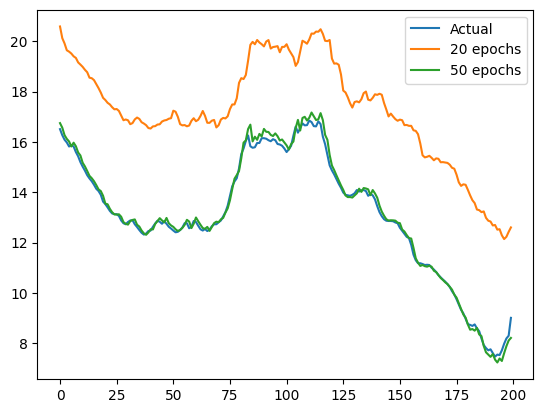

In [24]:
plt.plot(y_test_actual[:200], label="Actual")
plt.plot(y_pred_20[:200], label="20 epochs")
plt.plot(y_pred_50[:200], label="50 epochs")
plt.legend()
plt.show()